In [1]:
#Instalar librerias
!pip install catboost
!pip install shap
!pip install xgboost
!pip install optbinning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 213.9/213.9 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.1/28.1 MB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.8/302.8 kB 23.3 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.5
    Uninstalling protobuf-5.29.5:
      Successfully uninstalled protobuf-5.29.5
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf 0.13.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 5.26.1 which is incompatible.


In [2]:
#Importo librerias necesarias para el proceso de EDA (Esploratory Data Analysis)
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import folium
import numpy as np
from datetime import datetime

#Importo librerias necesarias para el proceso de Feature engineering y evaluación de modelos
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, roc_auc_score, ConfusionMatrixDisplay

#Importo librerias necesarias para ML
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import VotingClassifier
from catboost import CatBoostClassifier
import shap

import warnings
warnings.filterwarnings("ignore")
warnings.simplefilter(action='ignore', category=FutureWarning)

In [3]:
# obtener desde GitHub
url_flu_codificado = "https://raw.githubusercontent.com/jesustristan17/Curso-Machine-Learning/refs/heads/main/datasets/Flu%20Shot%20Learning/flu_filtrado_codificado.csv"
url_flu_test = "https://raw.githubusercontent.com/jesustristan17/Curso-Machine-Learning/refs/heads/main/datasets/Flu%20Shot%20Learning/flu_test_final_codificado.csv"

# Carga los datos
flu_codificado = pd.read_csv(url_flu_codificado)
print(flu_codificado.head())

flu_test = pd.read_csv(url_flu_test)
print(flu_test.head())


   opinion_seas_vacc_effective  opinion_seas_risk  doctor_recc_seasonal  \
0                          2.0                1.0                   0.0   
1                          4.0                2.0                   0.0   
2                          4.0                1.0                   0.0   
3                          5.0                4.0                   1.0   
4                          3.0                1.0                   0.0   

   age_group  opinion_h1n1_risk  opinion_h1n1_vacc_effective  \
0          3                1.0                          3.0   
1          1                4.0                          5.0   
2          0                1.0                          3.0   
3          4                3.0                          3.0   
4          2                3.0                          3.0   

   employment_industry  doctor_recc_h1n1  employment_occupation  \
0                   11               0.0                     11   
1                   13        

In [4]:
# Cargar dataset limpio
X = flu_codificado.drop(columns='seasonal_vaccine')
y = flu_codificado['seasonal_vaccine']

# Separar datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)


**Ajuste de regresión logistica**

Métricas de Regresión Logística:
Precision: 0.7644557823129252
Recall: 0.7229593888218737
F1 Score: 0.7431287456085968


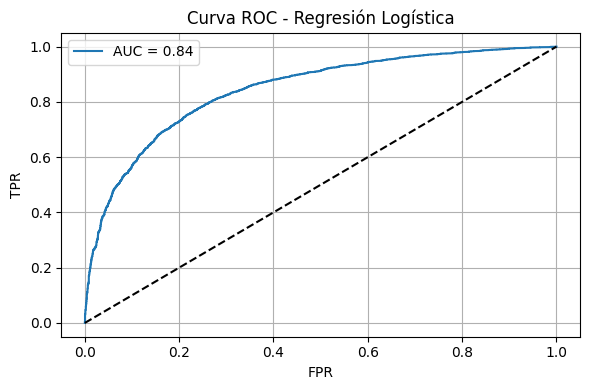

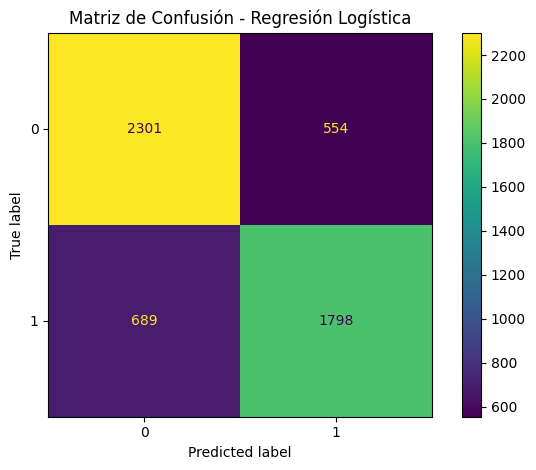

In [5]:
# Entrenamiento del modelo
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)

# Predicciones
y_pred_logreg = logreg.predict(X_test)
y_prob_logreg = logreg.predict_proba(X_test)[:, 1]


print("Métricas de Regresión Logística:")
print("Precision:", precision_score(y_test, y_pred_logreg))
print("Recall:", recall_score(y_test, y_pred_logreg))
print("F1 Score:", f1_score(y_test, y_pred_logreg))


# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_prob_logreg)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob_logreg):.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("Curva ROC - Regresión Logística")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Matriz de confusión
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_logreg)
plt.title("Matriz de Confusión - Regresión Logística")
plt.tight_layout()
plt.show()


**Trandformación WOE y Scoring**

In [9]:
from optbinning import BinningProcess

# Binning y transformación WOE
binning = BinningProcess(
    variable_names=X.columns.tolist(),
    categorical_variables=X.select_dtypes('object').columns.tolist()
)
binning.fit(X_train, y_train)

X_train_woe = binning.transform(X_train)
X_test_woe = binning.transform(X_test)


In [10]:
# Entrenamiento del modelo
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_woe, y_train)

# Predicciones
y_pred_logreg = logreg.predict(X_test_woe)
y_prob_logreg = logreg.predict_proba(X_test_woe)[:, 1]


In [11]:
print("Métricas de Regresión Logística:")
print("Precision:", precision_score(y_test, y_pred_logreg))
print("Recall:", recall_score(y_test, y_pred_logreg))
print("F1 Score:", f1_score(y_test, y_pred_logreg))


Métricas de Regresión Logística:
Precision: 0.7860847018150389
Recall: 0.7314032971451548
F1 Score: 0.7577588002499479


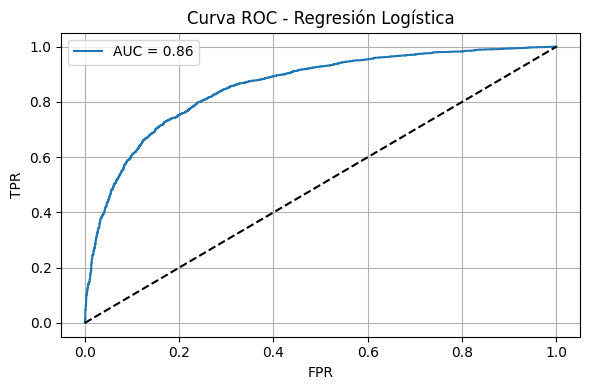

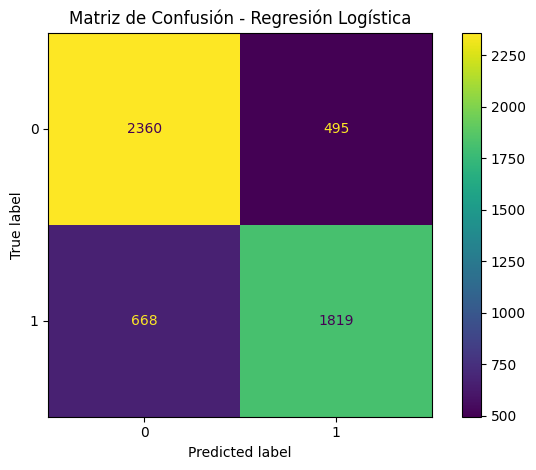

In [12]:
# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_prob_logreg)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob_logreg):.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("Curva ROC - Regresión Logística")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Matriz de confusión
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_logreg)
plt.title("Matriz de Confusión - Regresión Logística")
plt.tight_layout()
plt.show()


**Punto de corte óptimo por índice de Youden**

In [13]:
# Probabilidades predichas
y_scores = logreg.predict_proba(X_test_woe)[:, 1]

# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_scores)

# Índice de Youden
youden_index = tpr - fpr
optimal_idx = np.argmax(youden_index)
optimal_threshold = thresholds[optimal_idx]
optimal_threshold

np.float64(0.4202763867874171)

**Generación de scorecard**

In [15]:
# Parámetros del scorecard
PDO = 20  # Points to Double the Odds
score_ref = 600  # Score de referencia
odds_ref = 50    # Odds de referencia (ej. 1:50)

# Cálculo de Factor y Offset
Factor = PDO / np.log(2)
Offset = score_ref + Factor * np.log(odds_ref)


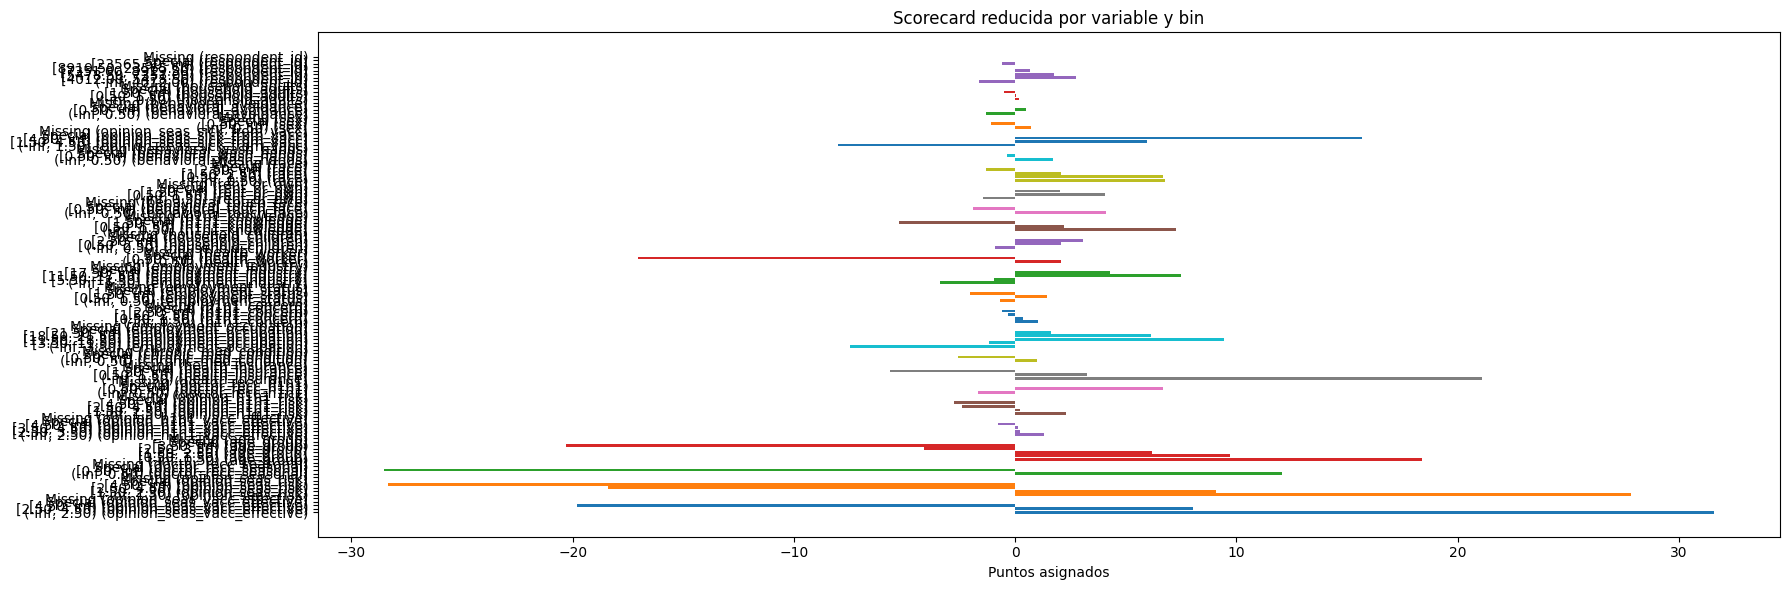

In [38]:
# Extraer coeficientes del modelo logístico
coefs = pd.Series(logreg.coef_[0], index=X_train_woe.columns)

# Calcular IV por variable
iv_ranking = []
for var in X.columns:
    binning_var = binning.get_binned_variable(var)
    iv = binning_var.binning_table.iv
    iv_ranking.append((var, iv))

iv_df = pd.DataFrame(iv_ranking, columns=['Variable', 'IV']).sort_values(by='IV', ascending=False)
top_vars_iv = iv_df.head(30)['Variable'].tolist()

# Construcción de scorecard
scorecard_reducida = pd.DataFrame()

for var in top_vars_iv:
    binning_var = binning.get_binned_variable(var)
    bin_table = binning_var.binning_table.build()

    bin_table['Variable'] = var
    bin_table['WOE'] = pd.to_numeric(bin_table['WoE'], errors='coerce')
    bin_table['Coef'] = coefs[var]
    bin_table['Score'] = -bin_table['WOE'] * bin_table['Coef'] * Factor

    scorecard_reducida = pd.concat([scorecard_reducida, bin_table[['Variable', 'Bin', 'WOE', 'Coef', 'Score']]])


# Visualización de scorecard reducida
plt.figure(figsize=(18, 6))
for var in scorecard_reducida['Variable'].unique():
    subset = scorecard_reducida[scorecard_reducida['Variable'] == var].dropna(subset=['Score'])
    plt.barh(subset['Bin'] + " (" + var + ")", subset['Score'])
plt.title("Scorecard reducida por variable y bin")
plt.xlabel("Puntos asignados")
plt.tight_layout()
plt.show()


In [39]:
# Score total para cada observación
scores_individuales = Offset + np.dot(X_train_woe[top_vars_iv], -coefs[top_vars_iv] * Factor)


In [40]:
# Selección de variables con mayor IV
X_train_woe_reducido = X_train_woe[top_vars_iv]
X_test_woe_reducido = X_test_woe[top_vars_iv]

# Entrenamiento del modelo logístico
logreg_reducido = LogisticRegression(max_iter=1000)
logreg_reducido.fit(X_train_woe_reducido, y_train)

# Coeficientes del modelo
coefs_reducidos = pd.Series(logreg_reducido.coef_[0], index=top_vars_iv)

# Cálculo del logit individual
logits_reducidos = X_test_woe_reducido.dot(coefs_reducidos)

# Cálculo del score individual
scores_reducidos = Offset - Factor * logits_reducidos

# Cálculo de la probabilidad desde el score
probabilidades_reducidas = 1 / (1 + np.exp(-(Offset - scores_reducidos) / Factor))

# Construcción del DataFrame final
flu_scores_reducido = X_test.copy()
flu_scores_reducido['score'] = scores_reducidos
flu_scores_reducido['probabilidad_vacuna'] = probabilidades_reducidas

# Mostrar primeros ejemplos
flu_scores_reducido[['score', 'probabilidad_vacuna']].head()



,score,probabilidad_vacuna
7314,826.297285,0.019249
18541,691.871231,0.674368
11811,722.674736,0.415917
22377,741.586689,0.269926
13716,742.980926,0.260510


In [41]:
flu_scores_reducido['seasonal_vaccine'] = flu_codificado.loc[X_test.index, 'seasonal_vaccine'].values


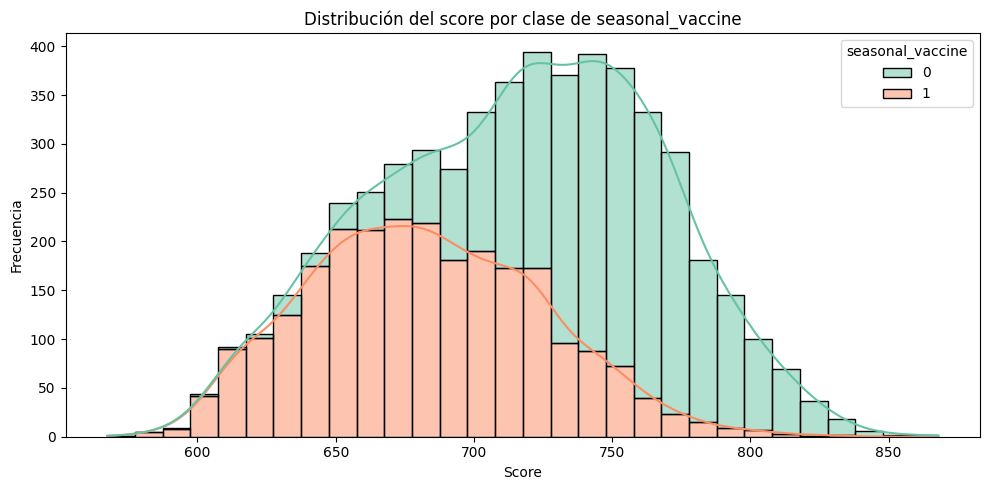

In [42]:
plt.figure(figsize=(10, 5))
sns.histplot(
    data=flu_scores_reducido,
    x='score',
    hue='seasonal_vaccine',
    bins=30,
    kde=True,
    palette='Set2',
    multiple='stack'
)
plt.title("Distribución del score por clase de seasonal_vaccine")
plt.xlabel("Score")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()


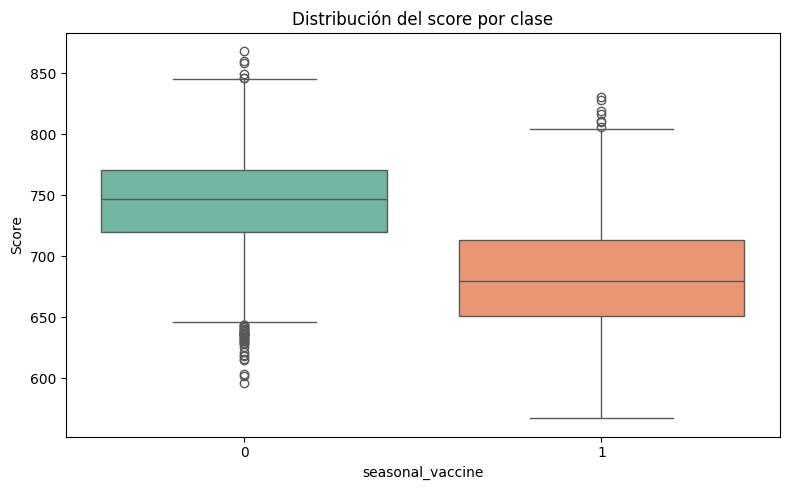

In [43]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=flu_scores_reducido,
    x='seasonal_vaccine',
    y='score',
    palette='Set2'
)
plt.title("Distribución del score por clase")
plt.xlabel("seasonal_vaccine")
plt.ylabel("Score")
plt.tight_layout()
plt.show()


**Corte de score optimo**

In [44]:

# Probabilidades predichas para la clase positiva
y_scores = logreg.predict_proba(X_test_woe)[:, 1]

# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_scores)

# Índice de Youden
youden_index = tpr - fpr
optimal_idx = np.argmax(youden_index)
optimal_threshold = thresholds[optimal_idx]

# umbral óptimo
print("Umbral óptimo (Youden):", optimal_threshold)
logit_opt = np.log(optimal_threshold / (1 - optimal_threshold))
score_opt = Offset - Factor * logit_opt
print("Score óptimo:", score_opt)


Umbral óptimo (Youden): 0.4202763867874171
Score óptimo: 722.1576607842726


In [45]:
from datetime import datetime

X_test_woe_2 = binning.transform(flu_test)
X_test_woe_2 = X_test_woe_2.drop(columns=['predicted_score'], errors='ignore')

# Obtener las probabilidades de la clase positiva
probs = logreg.predict_proba(X_test_woe_2)[:, 1]

# Redondear a tres decimales
flu_test['predicted_score'] = probs.round(3)

# Filtrar solo las columnas relevantes para exportar
pred_filtered = flu_test[['respondent_id', 'predicted_score']]

# Ordenar de mayor a menor por probabilidad
pred_filtered = pred_filtered.sort_values(by='predicted_score', ascending=False)

# Obtener la fecha y hora actual para nombrar el archivo
current_time = datetime.now().strftime("%Y-%m-%d_%H-%M")
file_name = f"regression_output_{current_time}.csv"

# Exportar a CSV sin el índice
pred_filtered.to_csv(file_name, index=False)

# Mostrar el resultado ordenado
pred_filtered



,respondent_id,predicted_score
4741,31448,0.993
13350,40057,0.991
1614,28321,0.991
11920,38627,0.990
1707,28414,0.990
...,...,...
16129,42836,0.006
21898,48605,0.006
14518,41225,0.005
24478,51185,0.005
